In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import os
import json

from utils_wind_analysis import get_wind_speed, get_wind_direction_in_degrees

In [ ]:
lake = 'lucerne'
base_folder = rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025'
date_ref = pd.to_datetime("2026-01-01 0:0:0")

In [5]:
bin_folder = os.path.join(base_folder, 'binary_data')
bin_u10_path = os.path.join(bin_folder, 'u10.bin')
bin_v10_path = os.path.join(bin_folder, 'v10.bin')
dtype='>f8'

grid_folder = os.path.join(base_folder, 'grid')

# Get grid characteristics

In [6]:
x = np.load(os.path.join(grid_folder, 'x.npy'))
y = np.load(os.path.join(grid_folder, 'y.npy'))

In [7]:
nx = len(x)
ny = len(y)

# Import binary data

In [8]:
with open(bin_u10_path, 'rb') as fid:
    binary_data_u10 = np.fromfile(fid, dtype=dtype)

In [9]:
with open(bin_v10_path, 'rb') as fid:
    binary_data_v10 = np.fromfile(fid, dtype=dtype)

In [10]:
nt = int(len(binary_data_u10) / nx /ny)
u10 = np.reshape(binary_data_u10, (nt,ny,nx))
v10 = np.reshape(binary_data_v10, (nt,ny,nx))

In [11]:
nt/24

60.041666666666664

# Create xarray

In [12]:
ds = xr.Dataset(
    data_vars={
        "u10": (("time", "y", "x"), u10),
        "v10": (("time", "y", "x"), v10),
    },
    coords={
        "x": x,
        "y": y,
        "time": pd.date_range(start=date_ref, periods=nt, freq="h"),
    },
)
ds["u10"].attrs.update({
    "long_name": "U10",
    "units": "m s-1"
})
ds["v10"].attrs.update({
    "long_name": "V10",
    "units": "m s-1"
})

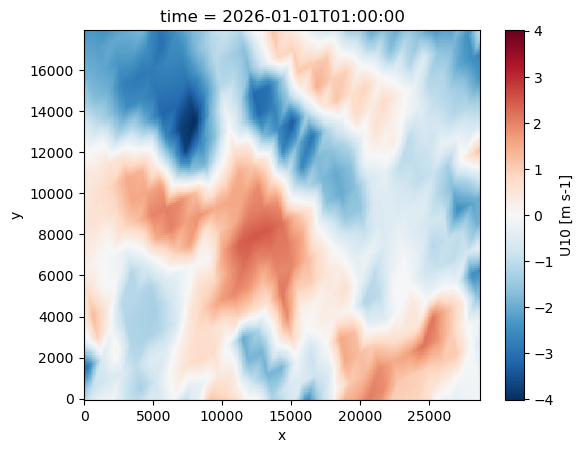

In [13]:
ds.isel(time=1).u10.plot()

# Lake mask

In [17]:
lake_mask = np.load(os.path.join(grid_folder, "mask_lake.npy"))

In [18]:
mask_da = xr.DataArray(
    lake_mask[0],
    dims=("y", "x"),
    coords={"y": y, "x": x},
)

ds = ds.where(mask_da)

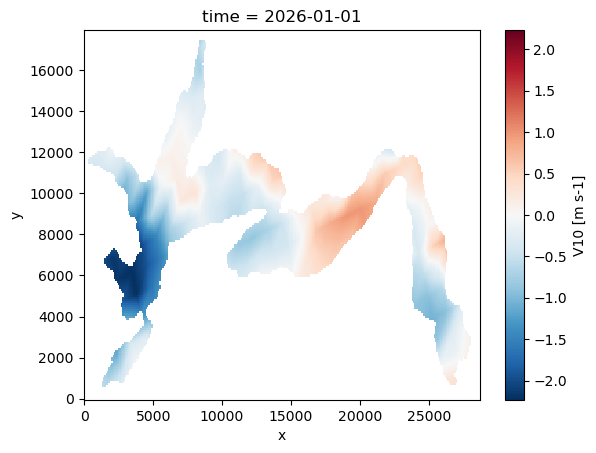

In [19]:
ds.v10.isel(time=0).plot()

# Add speed and direction

In [20]:
ds["speed"] = get_wind_speed(ds.u10, ds.v10)

In [21]:
ds["speed"].attrs.update({
    "long_name": "Wind speed at 10 m",
    "units": "m s-1"
})

In [22]:
with open(os.path.join(grid_folder, 'parameters.json'), 'r') as file:
    grid_angle = json.load(file)["rotation"]

In [23]:
ds["direction"] = get_wind_direction_in_degrees(ds.u10, ds.v10, grid_angle)

In [24]:
ds["direction"].attrs.update({
    "long_name": "Wind direction at 10 m (0° = coming from North)",
    "standard_name": "wind_from_direction",
    "units": "degree"
})

# Saving Netcdf

In [25]:
ds.to_netcdf(os.path.join(bin_folder, 'wind.nc'))

# Add vorticity

In [23]:
ds = xr.open_dataset(os.path.join(bin_folder, 'wind.nc'))

In [24]:
dvdx = ds.v10.differentiate("x")
dudy = ds.u10.differentiate("y")

vorticity = dvdx - dudy

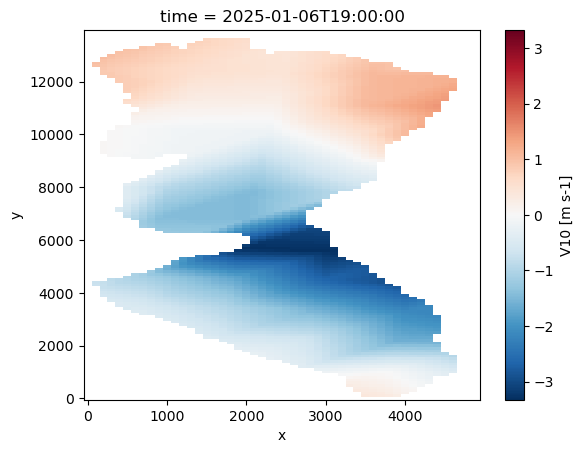

In [25]:
ds.v10.isel(time=139).plot()

In [26]:
import matplotlib.pyplot as plt

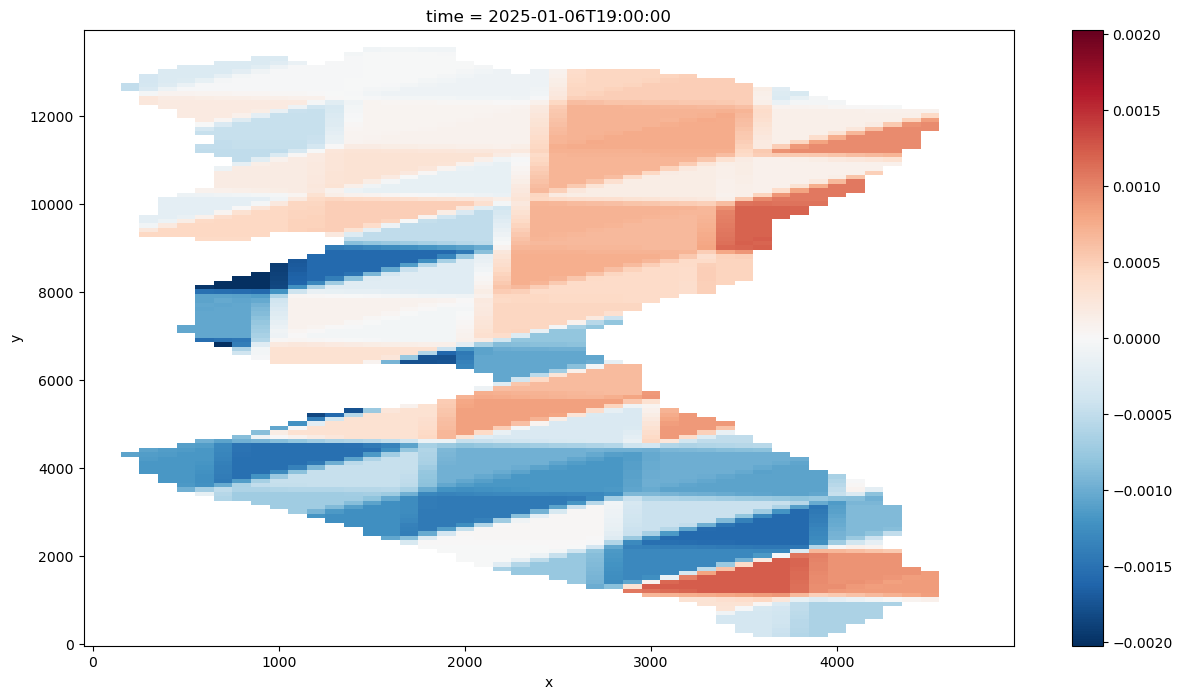

In [27]:
fig = plt.figure(figsize=(15,8))
vorticity.isel(time=139).plot()

In [28]:
vorticity = vorticity.rename("vorticity")
vorticity.attrs["long_name"] = "Relative vorticity"
vorticity.attrs["units"] = "s^-1"

In [29]:
ds["vorticity"] = vorticity

# Saving Netcdf

In [30]:
ds.to_netcdf(os.path.join(bin_folder, 'wind_with_vorticity.nc'))

# Merging DS

In [33]:
ds1 = xr.open_dataset(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025/binary_data/wind1.nc')
ds2 = xr.open_dataset(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025_2/binary_data/wind2.nc')

In [34]:
ds_merged = xr.concat([ds1,ds2], dim='time')

In [35]:
ds_merged = ds_merged.drop_duplicates(dim=['time'])

In [38]:
ds_merged.to_netcdf(rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025/binary_data/wind.nc')